# Determinants of High Hotel Ratings in Paris

## Introduction
In this notebook, I examine which hotel characteristics are associated with high user ratings in Paris using hotel-level data from a Europe-wide dataset. I focus on location and star ratings, then compare results across descriptive statistics and regression models. This analysis showcases data cleaning, visualization, and applied regression modeling in Python.

*Note: This notebook is part of an assignment submission for a Data Analysis course at CEU.*

## Data Loading & Cleaning

### Setup & imports
I start by importing the core libraries I’ll need for data handling, plotting, and regression modeling.

In [1]:
# Import core libraries for data handling, plotting, and regression modeling
import os
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf

# Ignore unimportant warnings
warnings.filterwarnings("ignore")

# Create outputs folder for saved figures
os.makedirs("../outputs", exist_ok=True)

In [2]:
# Load the datasets from OSF download links
prices_url = "https://osf.io/p6tyr/download"
features_url = "https://osf.io/utwjs/download"

prices = pd.read_csv(prices_url)
features = pd.read_csv(features_url)

In [3]:
# Quick sanity checks on rows/columns and key fields I’ll use later
features.shape, prices.shape

((22902, 15), (148021, 10))

### Baseline booking condition (hotel-level unit)
Because each hotel appears multiple times in the price data under different booking conditions, I first filter to a single baseline scenario. This keeps the unit of observation at the hotel level so comparisons are consistent.

In [4]:
# Keep the baseline booking condition: 1 night, weekday, non-holiday
prices_baseline = prices[
    (prices["nnights"] == 1)
    & (prices["weekend"] == 0)
    & (prices["holiday"] == 0)
].copy()

# Confirm we now have one row per hotel under the baseline scenario
prices_baseline[["hotel_id"]].nunique()

hotel_id    17223
dtype: int64

### Merge prices and features
Next, I merge the baseline price data with the hotel characteristics dataset. This gives me one combined table where each row represents a hotel with both its features and baseline price.

In [5]:
# Merge the two datasets to create a hotel-level Europe sample
europe = features.merge(prices_baseline, on="hotel_id", how="inner")

# Quick check: merged shape and one row per hotel_id in the baseline sample
europe.shape, europe["hotel_id"].nunique()

((17223, 24), 17223)

### Selecting City

The assignment requires selecting a city (other than Vienna) with at least 250 hotels **after appropriate filtering of the data**.  

Hence, I selected the city after the initial filtering step that defines the unit of observation (baseline condition for booking).

But the city was selected before applying any further data cleaning steps such as removing missing values.

I now check which cities have at least 250 hotels after the baseline filtering, because that’s part of the assignment requirement.

In [6]:
# Count hotels per city and keep cities with at least 250 hotels
city_counts = europe["city"].value_counts()
cities_250_plus = city_counts[city_counts >= 250].sort_values(ascending=False)

# Show a quick snapshot of qualifying cities
cities_250_plus.head(10)

city
Rome              2204
Paris             1698
Istanbul          1307
London            1118
Milan              919
Barcelona          647
St. Petersburg     623
Madrid             594
Prague             534
Berlin             521
Name: count, dtype: int64

In [7]:
# Keep only Paris hotels for the main analysis
city = "Paris"
paris_df = europe[europe["city"] == city].copy()

# Quick check on sample size
paris_df.shape

(1698, 24)

### Cleaning the Paris sample
Before modeling, I keep only the variables I need and drop hotels with missing values in the core regression fields. This way the descriptive stats and regressions all run on a consistent sample.

In [8]:
# Keep only the variables I use in the analysis
paris_df = paris_df[
    [
        "hotel_id",
        "city",
        "country",
        "distance",
        "stars",
        "rating",
        "price",
        "rating_reviewcount",
        "accommodation_type",
    ]
].copy()

# Preview the cleaned-down columns
paris_df.head()

,hotel_id,city,country,distance,stars,rating,price,rating_reviewcount,accommodation_type
10311,12215,Paris,France,7.6,4.0,3.7,179,16.0,Hotel
10312,12216,Paris,France,9.0,3.0,3.4,113,71.0,Hotel
10313,12217,Paris,France,8.9,2.0,3.2,57,70.0,Hotel
10314,12219,Paris,France,7.8,NaN,4.1,60,81.0,Hotel
10315,12220,Paris,France,2.4,4.0,4.5,233,175.0,Hotel


In [9]:
# Inspect missing values in the relevant variables in the dataset
paris_df.isna().sum().sort_values(ascending=False)

stars                 257
rating                  9
rating_reviewcount      9
hotel_id                0
city                    0
country                 0
distance                0
price                   0
accommodation_type      0
dtype: int64

In [10]:
# Drop observations missing core variables used in the models
paris_df = paris_df.dropna(subset=["rating", "stars", "distance"])

# Confirm remaining number of hotels after dropping missing values
paris_df.shape[0]

1440

In [11]:
# Inspect data types to ensure correctness
paris_df.dtypes

hotel_id                int64
city                      str
country                   str
distance              float64
stars                 float64
rating                float64
price                   int64
rating_reviewcount    float64
accommodation_type        str
dtype: object

In [12]:
# Enforce numeric types for regression variables (safety check)
paris_df["distance"] = pd.to_numeric(paris_df["distance"], errors="coerce")
paris_df["stars"] = pd.to_numeric(paris_df["stars"], errors="coerce")
paris_df["rating"] = pd.to_numeric(paris_df["rating"], errors="coerce")
paris_df["price"] = pd.to_numeric(paris_df["price"], errors="coerce")

# Drop any rows that became NaN due to coercion
paris_df = paris_df.dropna(subset=["distance", "stars", "rating", "price"])

# Confirm types and final sample size
paris_df.dtypes, paris_df.shape[0]

(hotel_id                int64
 city                      str
 country                   str
 distance              float64
 stars                 float64
 rating                float64
 price                   int64
 rating_reviewcount    float64
 accommodation_type        str
 dtype: object,
 1440)

### Define the outcome variable
I now convert the continuous user rating into a simple binary indicator so I can model the probability a hotel is “highly rated”. I define highly rated as rating ≥ 4, matching the original setup.

In [13]:
# Create binary dependent variable: highly_rated (1 if rating >= 4)
paris_df["highly_rated"] = (paris_df["rating"] >= 4).astype(int)

# Check the outcome distribution
paris_df["highly_rated"].value_counts()

highly_rated
1    765
0    675
Name: count, dtype: int64

## Exploratory Data Analysis

### Descriptive comparisons
I start with simple descriptive comparisons to see how distance, stars, and price differ between highly rated and not highly rated hotels. This helps me understand the patterns before running any models.

In [14]:
# Share of highly rated hotels
highly_rated_share = paris_df["highly_rated"].value_counts(normalize=True)

# Compare average characteristics by rating group
rating_means = paris_df.groupby("highly_rated")[["distance", "stars", "price"]].mean()

highly_rated_share, rating_means

(highly_rated
 1    0.53125
 0    0.46875
 Name: proportion, dtype: float64,
               distance     stars       price
 highly_rated                                
 0             3.419704  2.780741  144.915556
 1             2.234248  3.637908  238.216993)

**Interpretation**
About 53% of hotels in Paris are classified as highly rated. Highly rated hotels are, on average, closer to the city centre, have higher star ratings, and charge higher prices than hotels that are not highly rated. This matches what I’d expect if location and formal quality signals matter for user ratings.

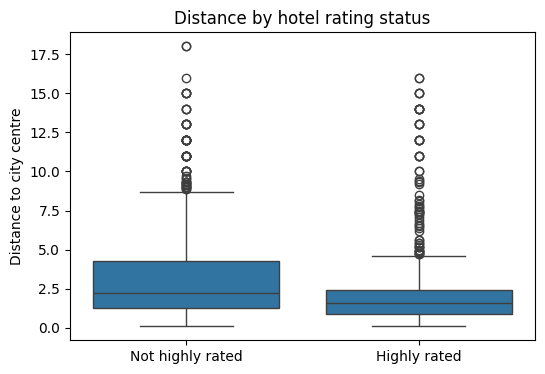

In [15]:
# Plot 1: Distance to city centre by hotel rating status (boxplot)
plt.figure(figsize=(6, 4))
sns.boxplot(data=paris_df, x="highly_rated", y="distance")
plt.xticks([0, 1], ["Not highly rated", "Highly rated"])
plt.xlabel("")
plt.ylabel("Distance to city centre")
plt.title("Distance by hotel rating status")

plt.savefig("../outputs/boxplot_distance_rating.png", dpi=150, bbox_inches="tight")
plt.show()

**Interpretation**
The box plot shows that highly rated hotels are generally closer to the city centre than hotels that are not highly rated. The median distance is clearly lower for the highly rated group, and the distribution is more concentrated near the centre. This suggests location could be an important predictor of high ratings.

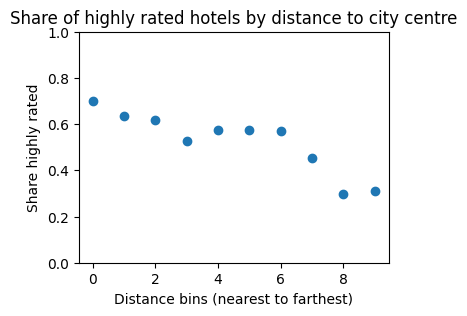

In [16]:
# Plot 2: Share of highly rated hotels across distance bins (bin scatter)
# Create distance bins (10 quantiles)
paris_df["distance_bin"] = pd.qcut(paris_df["distance"], q=10)

# Compute mean outcome by bin
bin_means = (
    paris_df.groupby("distance_bin")["highly_rated"].mean().reset_index()
 )

# Plot points only (no line)
plt.figure(figsize=(4, 3))
plt.scatter(range(len(bin_means)), bin_means["highly_rated"])
plt.xlabel("Distance bins (nearest to farthest)")
plt.ylabel("Share highly rated")
plt.title("Share of highly rated hotels by distance to city centre")
plt.ylim(0, 1)

plt.savefig("../outputs/binscatter_distance.png", dpi=150, bbox_inches="tight")
plt.show()

**Interpretation**
The bin scatter shows a clear downward pattern: as distance from the city centre increases, the share of highly rated hotels falls. Hotels in the closest bins have much higher probabilities of being highly rated compared to hotels farther out. This again points to distance as a strong correlate of rating outcomes.

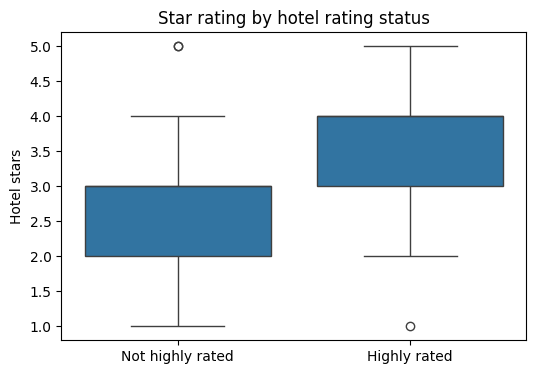

In [17]:
# Plot 3: Hotel star rating by hotel rating status (boxplot)
plt.figure(figsize=(6, 4))
sns.boxplot(data=paris_df, x="highly_rated", y="stars")
plt.xticks([0, 1], ["Not highly rated", "Highly rated"])
plt.xlabel("")
plt.ylabel("Hotel stars")
plt.title("Star rating by hotel rating status")

plt.savefig("../outputs/boxplot_stars_rating.png", dpi=150, bbox_inches="tight")
plt.show()

**Interpretation**
This box plot shows that highly rated hotels tend to have higher star classifications. The distribution for the highly rated group is shifted up, with a higher median and more mass at 4–5 stars. This suggests formal hotel quality (stars) aligns closely with user ratings in Paris.

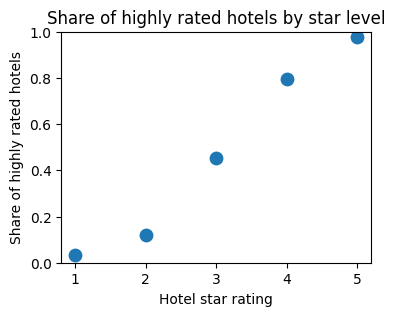

In [18]:
# Plot 4: Share of highly rated hotels by star level (scatter)
# Compute share of highly rated hotels by star level
stars_share = (
    paris_df.groupby("stars")["highly_rated"].mean().reset_index()
 )

plt.figure(figsize=(4, 3))
plt.scatter(stars_share["stars"], stars_share["highly_rated"], s=80)
plt.xlabel("Hotel star rating")
plt.ylabel("Share of highly rated hotels")
plt.title("Share of highly rated hotels by star level")
plt.ylim(0, 1)

plt.savefig("../outputs/scatter_stars_highly_rated.png", dpi=150, bbox_inches="tight")
plt.show()

**Interpretation**
The scatter plot shows a strong positive relationship between stars and the share of hotels that are highly rated. Moving from lower to higher star levels increases the probability of being highly rated quite sharply. This makes sense if stars capture amenities and service quality that guests value.

## Regression Models

### Linear Probability Model (LPM)
After exploring the patterns visually, I estimate a linear probability model using distance and stars as predictors. This gives a simple baseline estimate of how these features relate to the probability of being highly rated.

In [19]:
# Linear Probability Model (LPM) with robust standard errors (HC1)
lpm = smf.ols("highly_rated ~ distance + stars", data=paris_df).fit(cov_type="HC1")

lpm.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:           highly_rated   R-squared:                       0.272
Model:                            OLS   Adj. R-squared:                  0.271
Method:                 Least Squares   F-statistic:                     497.1
Date:                Tue, 17 Mar 2026   Prob (F-statistic):          8.23e-165
Time:                        20:41:40   Log-Likelihood:                -814.11
No. Observations:                1440   AIC:                             1634.
Df Residuals:                    1437   BIC:                             1650.
Df Model:                           2                                         
Covariance Type:                  HC1                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.3418      0.042     -8.105      0.000      -0.424      -0.259
distance      -0.0210      0.004     -5.320      0.000      -0.029      -0.013
stars          0.2879      0.011     26.918      0.000       0.267       0.309
==============================================================================
Omnibus:                      856.233   Durbin-Watson:                   1.874
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               83.709
Skew:                          -0.095   Prob(JB):                     6.65e-19
Kurtosis:                       1.834   Cond. No.                         21.5
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity robust (HC1)
"""

**Interpretation**
In the LPM, distance to the city centre is negatively associated with being highly rated, while hotel stars are positively associated. A one-kilometre increase in distance corresponds to a lower probability of being highly rated, and an additional star corresponds to a noticeably higher probability. Even though the LPM is simple, the direction of the relationships is clear and matches the EDA.

### Logit and probit models
Because the dependent variable is binary, I also estimate logit and probit models using the same predictors. These models keep predicted probabilities in a valid 0–1 range and are commonly used for this type of outcome.

In [20]:
# Logit model
logit_model = smf.logit("highly_rated ~ distance + stars", data=paris_df).fit(disp=False)

logit_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:           highly_rated   No. Observations:                 1440
Model:                          Logit   Df Residuals:                     1437
Method:                           MLE   Df Model:                            2
Date:                Tue, 17 Mar 2026   Pseudo R-squ.:                  0.2347
Time:                        20:41:57   Log-Likelihood:                -761.75
converged:                       True   LL-Null:                       -995.32
Covariance Type:            nonrobust   LLR p-value:                3.656e-102
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -4.8620      0.333    -14.582      0.000      -5.515      -4.208
distance      -0.1362      0.023     -5.878      0.000      -0.182      -0.091
stars          1.6674      0.102     16.278      0.000       1.467       1.868
==============================================================================
"""

**Interpretation**
The logit model again shows a negative association between distance and the likelihood of being highly rated, and a positive association for stars. Both predictors are statistically significant in the output. Overall, the signs are consistent with the LPM and the descriptive patterns I saw earlier.

In [21]:
# Probit model
probit_model = smf.probit("highly_rated ~ distance + stars", data=paris_df).fit(disp=False)

probit_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                          Probit Regression Results                           
==============================================================================
Dep. Variable:           highly_rated   No. Observations:                 1440
Model:                         Probit   Df Residuals:                     1437
Method:                           MLE   Df Model:                            2
Date:                Tue, 17 Mar 2026   Pseudo R-squ.:                  0.2349
Time:                        20:42:04   Log-Likelihood:                -761.52
converged:                       True   LL-Null:                       -995.32
Covariance Type:            nonrobust   LLR p-value:                2.911e-102
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -2.8692      0.185    -15.504      0.000      -3.232      -2.506
distance      -0.0803      0.013     -5.979      0.000      -0.107      -0.054
stars          0.9843      0.056     17.646      0.000       0.875       1.094
==============================================================================
"""

**Interpretation**
The probit results tell the same story as the logit model. Distance is negatively related to being highly rated, while stars are positively related. The statistical significance and direction of effects are stable across these alternative specifications, which makes the findings feel more robust.

In [22]:
# Marginal effects at the mean for interpretability
logit_mfx = logit_model.get_margeff(at="mean")
probit_mfx = probit_model.get_margeff(at="mean")

logit_mfx.summary(), probit_mfx.summary()

(<class 'statsmodels.iolib.summary.Summary'>
 """
         Logit Marginal Effects       
 Dep. Variable:           highly_rated
 Method:                          dydx
 At:                              mean
                 dy/dx    std err          z      P>|z|      [0.025      0.975]
 ------------------------------------------------------------------------------
 distance      -0.0338      0.006     -5.870      0.000      -0.045      -0.023
 stars          0.4144      0.025     16.310      0.000       0.365       0.464
 """,
 <class 'statsmodels.iolib.summary.Summary'>
 """
        Probit Marginal Effects       
 Dep. Variable:           highly_rated
 Method:                          dydx
 At:                              mean
                 dy/dx    std err          z      P>|z|      [0.025      0.975]
 ------------------------------------------------------------------------------
 distance      -0.0319      0.005     -5.975      0.000      -0.042      -0.021
 stars          0.3910

**Interpretation**
The marginal effects make the logit and probit coefficients easier to understand in probability terms. A one-kilometre increase in distance lowers the probability of being highly rated by a few percentage points, while an additional star increases it by a large amount. The magnitudes are similar between logit and probit, which is reassuring.

### Predicted probabilities
To make the model results more intuitive, I compute predicted probabilities across a range of distances for a few representative star levels. This shows how location and stars jointly shape the chance of being highly rated.

In [23]:
# Create the prediction grid across the central range of distances
distance_grid = np.linspace(
    paris_df["distance"].quantile(0.05),
    paris_df["distance"].quantile(0.95),
    60,
 )

# Use the same representative star values as in the original analysis
stars_vals = [3, 4, 5]

pred_df = pd.DataFrame({
    "distance": np.repeat(distance_grid, len(stars_vals)),
    "stars": stars_vals * len(distance_grid),
})

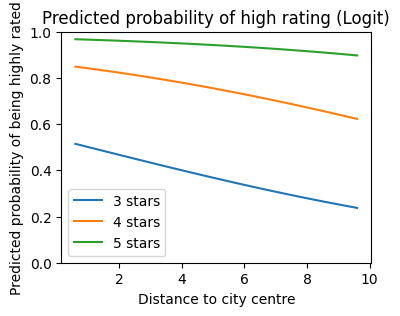

In [24]:
# Predict probabilities from logit and probit
pred_df["p_logit"] = logit_model.predict(pred_df)
pred_df["p_probit"] = probit_model.predict(pred_df)

# Plot predicted probabilities from the logit model
plt.figure(figsize=(4, 3))
for s in stars_vals:
    sub = pred_df[pred_df["stars"] == s]
    plt.plot(sub["distance"], sub["p_logit"], label=f"{s} stars")

plt.xlabel("Distance to city centre")
plt.ylabel("Predicted probability of being highly rated")
plt.title("Predicted probability of high rating (Logit)")
plt.legend()
plt.ylim(0, 1)

plt.savefig("../outputs/predicted_probabilities_logit.png", dpi=150, bbox_inches="tight")
plt.show()

**Interpretation**
The predicted probability curves decline as distance from the city centre increases for every star category. At any given distance, higher-star hotels have much higher predicted probabilities of being highly rated. This visualization makes it clear that location and stars both matter, and that stars shift the whole relationship upward.

## Conclusion
Across descriptive statistics, visuals, and regression models, the same pattern shows up consistently for Paris hotels. Hotels closer to the city centre are more likely to be highly rated, and higher star classifications are strongly associated with higher rating outcomes. The logit and probit results match the linear probability model in direction, and the marginal effects make the magnitudes easier to interpret. Overall, the analysis is descriptive rather than causal, but it provides a clear and robust picture of what correlates with high hotel ratings in the Paris sample.